In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

# Générer des données de ventes
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
n = len(dates)

# Tendance + saisonnalité + bruit
tendance = np.linspace(100000, 200000, n)
saisonnalite = 30000 * np.sin(2 * np.pi * np.arange(n) / 365)
bruit = np.random.normal(0, 10000, n)

ventes = tendance + saisonnalite + bruit

df_ventes = pd.DataFrame({
    'date': dates,
    'ventes': ventes.astype(int),
    'jour_semaine': dates.dayofweek,
    'mois': dates.month,
    'jour_mois': dates.day,
    'trimestre': dates.quarter
})

print(df_ventes.head())
print(f"Shape : {df_ventes.shape}")
df_ventes.to_csv('/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/datasets/klaaro_ventes.csv', index=False)

        date  ventes  jour_semaine  mois  jour_mois  trimestre
0 2023-01-01  104967             6     1          1          1
1 2023-01-02   99270             0     1          2          1
2 2023-01-03  107783             1     1          3          1
3 2023-01-04  117189             2     1          4          1
4 2023-01-05  100270             3     1          5          1
Shape : (731, 6)


In [5]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
import os
import joblib

# Features et target
features = ['jour_semaine', 'mois', 'jour_mois', 'trimestre']
X = df_ventes[features]
y = df_ventes['ventes']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model_xgb.fit(X_train, y_train)

# Évaluer
predictions = model_xgb.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE  : {mae:.2f} FCFA")
print(f"RMSE : {rmse:.2f} FCFA")

# Sauvegarder
os.makedirs('/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/XGBoost', exist_ok=True)
joblib.dump(model_xgb, '/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/XGBoost/xgboost_ventes.pkl')
print("Modele XGBoost sauvegarde !")

MAE  : 33282.87 FCFA
RMSE : 35893.53 FCFA
Modele XGBoost sauvegarde !


In [10]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os


In [11]:
def prepare_features(df, date_col, target_col):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Features temporelles génériques
    df['jour_semaine'] = df[date_col].dt.dayofweek
    df['mois'] = df[date_col].dt.month
    df['jour_mois'] = df[date_col].dt.day
    df['trimestre'] = df[date_col].dt.quarter
    df['annee'] = df[date_col].dt.year
    df['semaine'] = df[date_col].dt.isocalendar().week.astype(int)

    # Lag features — valeurs passées
    df['lag_1'] = df[target_col].shift(1)   # valeur hier
    df['lag_7'] = df[target_col].shift(7)   # valeur il y a 7 jours
    df['lag_30'] = df[target_col].shift(30) # valeur il y a 30 jours

    # Moyennes mobiles
    df['moyenne_7j'] = df[target_col].rolling(7).mean()
    df['moyenne_30j'] = df[target_col].rolling(30).mean()

    # Supprimer les NaN
    df = df.dropna()

    return df


In [12]:
def train_generic_model(df, date_col, target_col):

    # Entraînement du modèle XGBoost générique sur n'importe quelle série temporelle

    df = prepare_features(df, date_col, target_col)

    features = ['jour_semaine', 'mois', 'jour_mois', 'trimestre',
                'annee', 'semaine', 'lag_1', 'lag_7', 'lag_30',
                'moyenne_7j', 'moyenne_30j']

    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print(f"Colonne predite : {target_col}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"Erreur relative : {(mae / y.mean() * 100):.1f}%")

    return model, features

In [13]:
# Test avec les ventes
model_xgb, features = train_generic_model(df_ventes, 'date', 'ventes')

# Sauvegarder
os.makedirs('/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/XGBoost', exist_ok=True)
joblib.dump(model_xgb, '/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/XGBoost/xgboost_generic.pkl')
joblib.dump(features, '/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/XGBoost/features.pkl')
print("Modele generique sauvegarde !")

Colonne predite : ventes
MAE  : 8683.23
RMSE : 10994.07
Erreur relative : 5.7%
Modele generique sauvegarde !


                                                                                Prediction future

        date         ventes
0 2025-01-01  191353.343750
1 2025-01-02  200757.140625
2 2025-01-03  200665.265625
3 2025-01-04  189878.406250
4 2025-01-05  187329.031250
5 2025-01-06  198074.812500
6 2025-01-07  187535.718750
7 2025-01-08  196567.093750
8 2025-01-09  190143.265625
9 2025-01-10  193509.484375


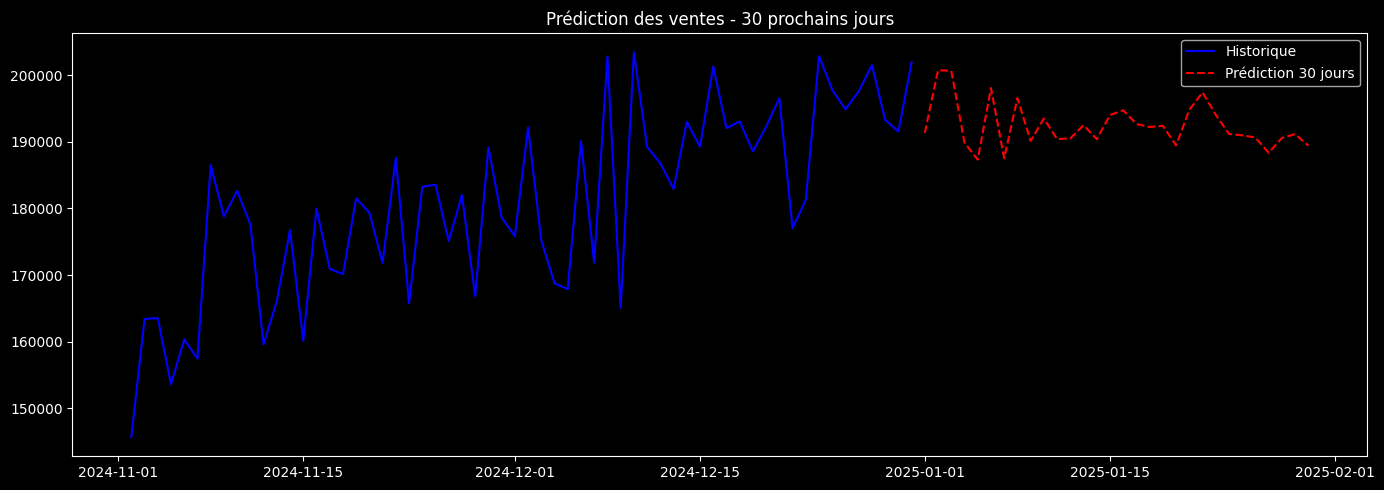

In [14]:
from matplotlib import pyplot as plt


def predict_future(model, df, date_col, target_col, n_days=30):
    """
    Prédit les n_days prochains jours
    """
    df = prepare_features(df, date_col, target_col)

    predictions = []
    last_values = df[target_col].values.tolist()
    last_date = pd.to_datetime(df[date_col].iloc[-1])

    for i in range(n_days):
        next_date = last_date + pd.Timedelta(days=i+1)

        # Features temporelles
        features_dict = {
            'jour_semaine': next_date.dayofweek,
            'mois': next_date.month,
            'jour_mois': next_date.day,
            'trimestre': next_date.quarter,
            'annee': next_date.year,
            'semaine': next_date.isocalendar()[1],
            'lag_1': last_values[-1],
            'lag_7': last_values[-7] if len(last_values) >= 7 else last_values[0],
            'lag_30': last_values[-30] if len(last_values) >= 30 else last_values[0],
            'moyenne_7j': np.mean(last_values[-7:]),
            'moyenne_30j': np.mean(last_values[-30:])
        }

        X_pred = pd.DataFrame([features_dict])
        pred = model.predict(X_pred)[0]
        predictions.append({'date': next_date, target_col: pred})
        last_values.append(pred)

    return pd.DataFrame(predictions)

# Test — prédire 30 jours
future = predict_future(model_xgb, df_ventes, 'date', 'ventes', n_days=30)
print(future.head(10))

# Visualiser
plt.figure(figsize=(14, 5))
plt.plot(df_ventes['date'].tail(60), df_ventes['ventes'].tail(60),
         label='Historique', color='blue')
plt.plot(future['date'], future['ventes'],
         label='Prédiction 30 jours', color='red', linestyle='--')
plt.legend()
plt.title('Prédiction des ventes - 30 prochains jours')
plt.tight_layout()
plt.show()

In [17]:
import psutil
ram = psutil.virtual_memory()
print(f"RAM totale : {ram.total / 1024**3:.1f} GB")
print(f"RAM disponible : {ram.available / 1024**3:.1f} GB")

RAM totale : 15.3 GB
RAM disponible : 3.7 GB
